# Growing Planets Produce Extreme Dust Signatures

Philip J. Carter and Zoë M. Leinhardt

<div style="font-size: 80%;">
School of Physics, University of Bristol</br>
</div>

</br>

*Modified from a manuscript accepted for publication in ApJL*

---
> Collisions between planetary bodies are essential to the assembly of rocky planets like the Earth, but they are extremely difficult to observe. 
We therefore rely on indirect signatures of planetary impacts such as extreme debris disks – bright infrared excesses around other stars. Extreme debris disks are thought to be the result of energetic collisions that ejected large amounts of vaporized rock which rapidly condensed into mm- or cm-sized dust. 
However, previously there has been no clear way to relate the observed mass of dust to the collision that produced it. 
Here, we show that the colliding bodies required are orders of magnitude more massive than the mass of dust observed. 
We find that more massive extreme debris disks require proportionally larger colliding bodies. 
As a consequence, the most massive observed extreme debris disks require collisions of Mars- to Earth-mass bodies.
Extreme debris disks thus reveal the ongoing formation of rocky planets comparable in size to the rocky planets of our own solar system.

*collisional processes(2286) – debris disks(363) – planetesimals(1259) – planet formation(1241)*

---

**Imports and settings**

In [1]:
### ImpactVaporEjecta.ipynb

import numpy as npy
import scipy
from planit import planit
import matplotlib
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

txsz = 11
matplotlib.rc('font',size=txsz)
matplotlib.rc('axes',titlesize=12)
matplotlib.rc('axes',labelsize=11)
matplotlib.rc('xtick',labelsize=10)
matplotlib.rc('ytick',labelsize=10)
matplotlib.rc('legend',fontsize=10)

matplotlib.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
matplotlib.rc('text',usetex=True)
matplotlib.rc('mathtext',fontset='custom')
#matplotlib.rc('text.latex',preamble=r'\usepackage[helvet]{sfmath}')
matplotlib.rc('xtick',direction='in')
matplotlib.rc('ytick',direction='in')
matplotlib.rc('ytick',right=True)
matplotlib.rc('xtick',top=True)
matplotlib.rc('legend',numpoints=1)
matplotlib.rc('legend',frameon=False)

path = 'data/'

**Load data**

In [ ]:
imploc1 = path + 'cM1e-3p0mr1e-2v3.00b0.500N1e6Fo70S303Fe30S193/'
imploc2 = path + 'cM1e-1p0mr5e-1v4.00b0.870N1e6Fo70S303FeSi30S182/'
imploc3 = path + 'cM1p0mr1e-1v5.00b0.707N1e6Fo70S303FeSi30S181/'
imploc4 = path + 'cM1e-1p0mr1e-1v12.00b0.500N1e6Fo70S303FeSi30S182/'

seq1 = [0,19,24,92,170,210,421]
seq2 = [0,19,23,42,120,190,421]
seq3 = [0,19,24,52,120,190,421]
seq4 = [0,19,24,52,100,190,421]

imp1 = planit.Impact()
imp1.load(imploc1,inter=1,thermo=True,flist=seq1)
imp2 = planit.Impact()
imp2.load(imploc2,inter=1,thermo=True,flist=seq2)
imp3 = planit.Impact()
imp3.load(imploc3,inter=1,thermo=True,flist=seq3)
imp4 = planit.Impact()
imp4.load(imploc4,inter=1,thermo=True,flist=seq4)

seq = [1,2,3,4,5,6]

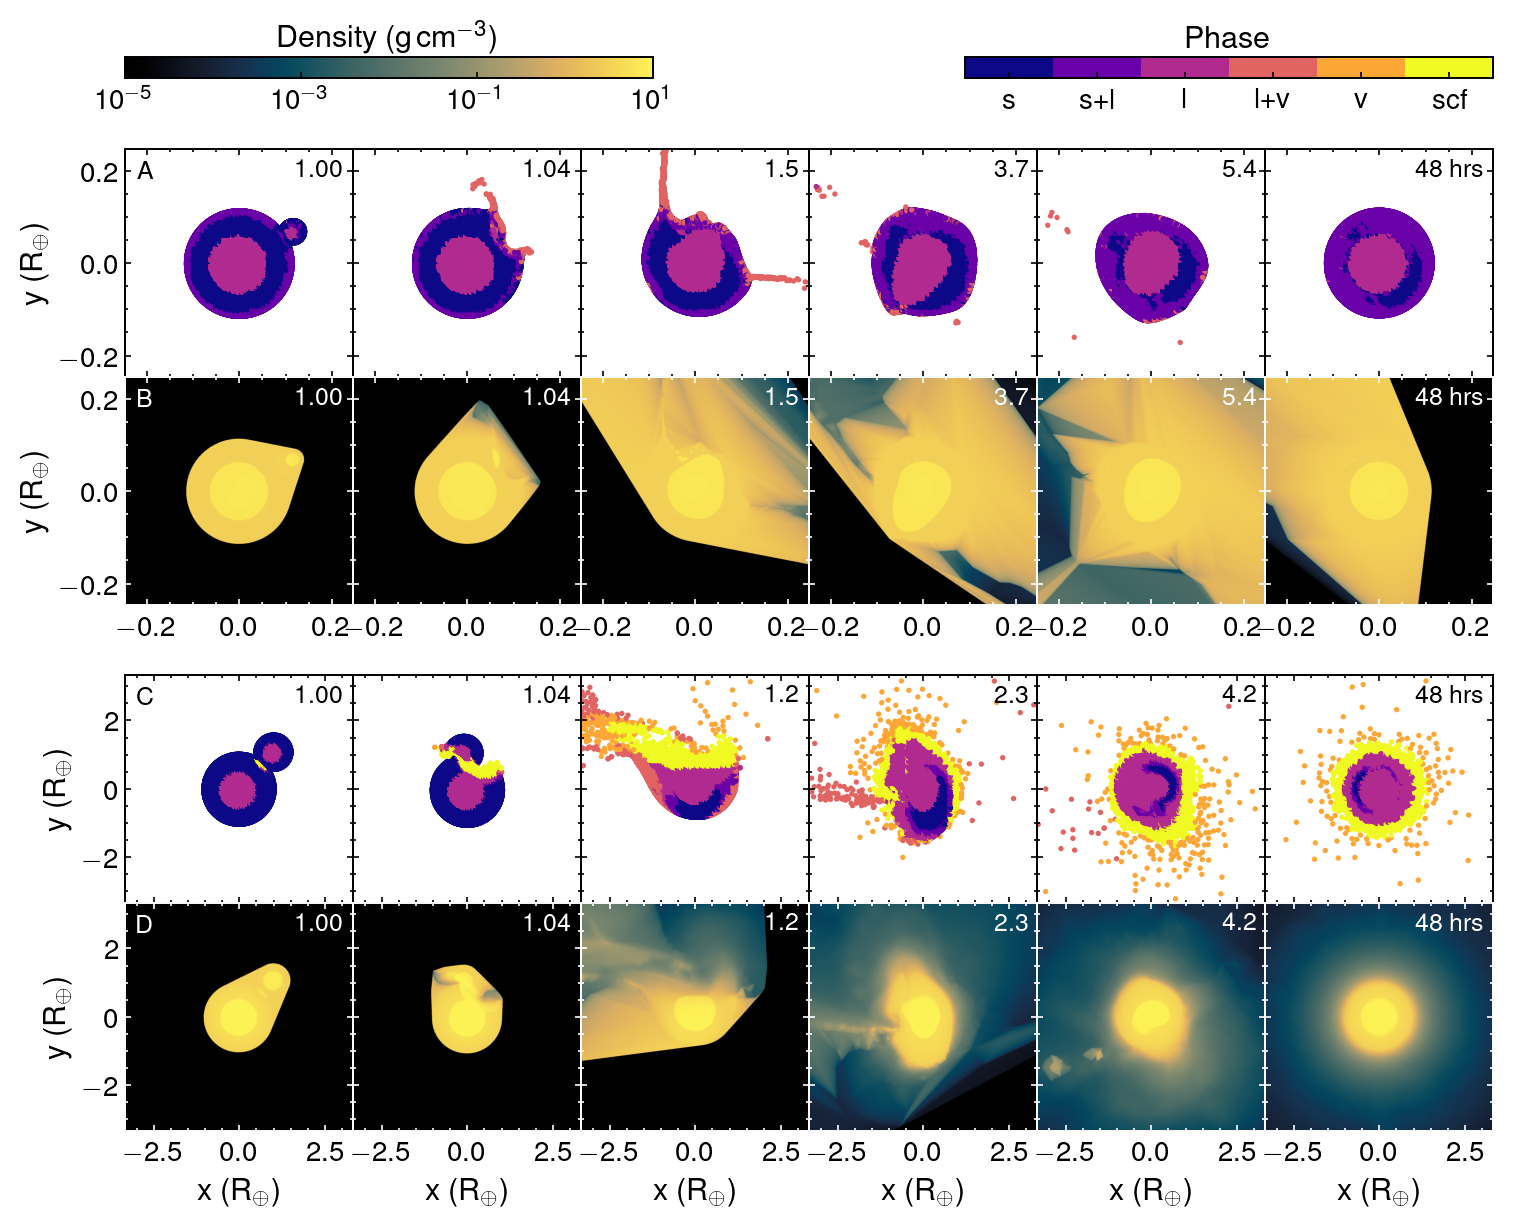

In [ ]:
planit.multiplotseq([imp1,imp3],seqs=[seq,seq],types=['phase','rho'],zoom=[8.1,2.4],scale='earth',uppercaselab=True)

In [3]:
dustM = [1.1e22,5.37e22,5.4e23,3.5e24,3e24,1.1e21,3.6e22,9e21,3.4e21,1e23,2e22,6.8e20,6e23,3e20,]
infM = [1.1e22,5.37e22,5.4e23,3.5e24,3e24,1.1e21,3.6e22,9e21,1.7e22,1e23,2e22,6.8e20,6e23,3e20,]
system = ['ID8','P1121','HD113766','HD145263','HD172555','RZ Psc','V488 Per',r'$\eta$ Crv',r'TYC 4209','HD166191','HD23514','HD15407A','BD +20 307','HD69830']
variable = [True, True, True, False, False,True,True,False,True,True,True,False,False,False,]
ref = [r'\postnote{\citealp{Meng14}}',r'\postnote{\citealp{Su19}}',r'\postnote{\citealp{Olofsson13}},\postnote{\citealp{Su20}}',r'\postnote{\citealp{Lisse20}}',r'\postnote{\citealp{Su20}},\postnote{\citealp{Lisse09}}',r'\postnote{\citealp{Su23}},\postnote{\citealp{deWit13}}',r'\postnote{\citealp{Rieke21}}',r'\postnote{\citealp{Lisse12}}',r'\postnote{\citealp{Moor22}}',r'\postnote{\citealp{Su22}}',r'\postnote{\citealp{Rhee08}}',r'\postnote{\citealp{Fujiwara12}}',r'\postnote{\citealp{Weinberger11}}',r'\postnote{\citealp{Lisse07}},\postnote{\citealp{Tanner15}}',]
Rin = [0.32,0.2,0.6,3.0,5.8,0.7,0.3,3.0,0.3,0.6,0.25,0.6,0.85,0.93,]
Mstar = [1.,1.,1.4,1.4,1.86,0.9,0.8,1.5,1.0,1.6,1.25,1.4,2.7,0.86,]
age = [35,80,17,11,20,30,80,1400,275,10,100,80,1000,7500] # Myr

vap scaling fac: 1.2173066653544745e-06
fit param: 5.9146 Mtarg fac (ecc): 1.2518492770973427e-07 Mtarg fac (vesc): 8.282180235795683e-05
fit param: 1.0062 power (ecc): 0.9938382031405287 power (vesc): 0.5963029218843172


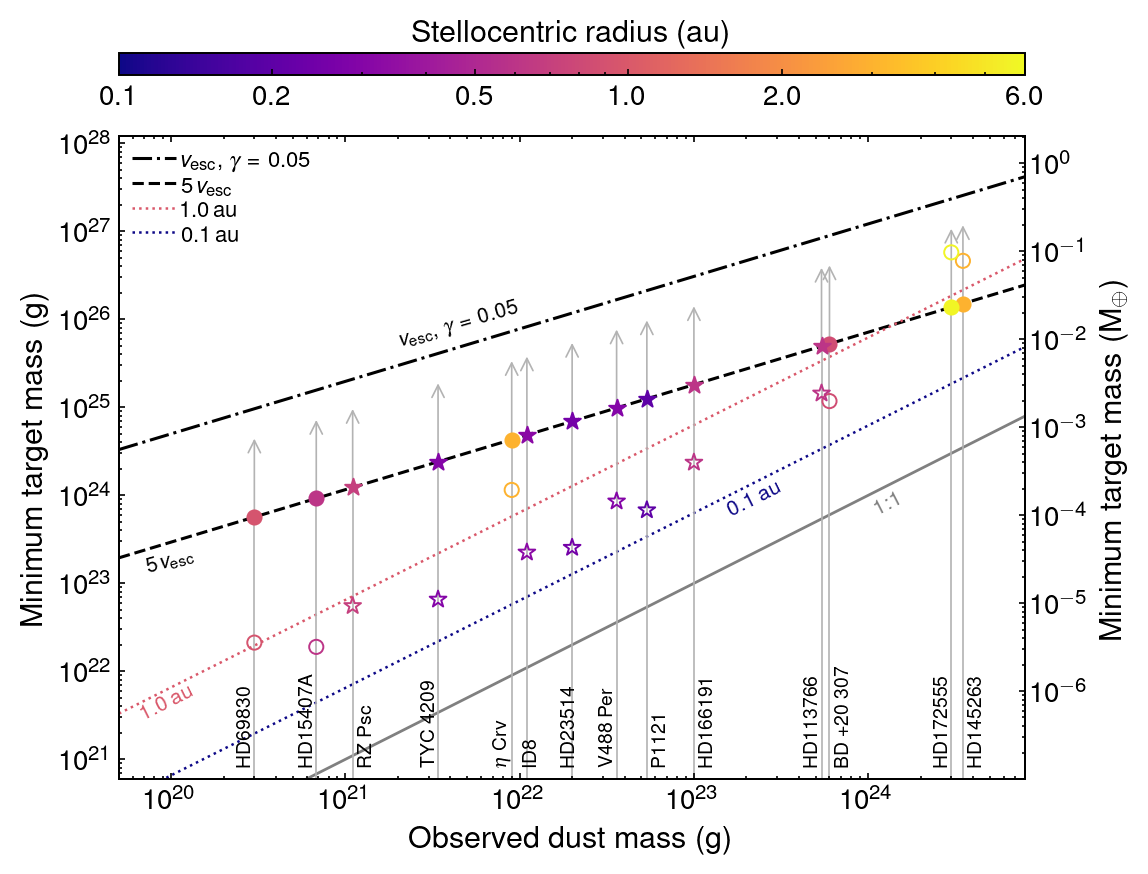

In [11]:
plt.close()

a = 0.3 # au
##Mstar = 1. # solar M

G=6.674e-11 # SI
Mearth = 5.972e27 #g

powerparam = 1.0062 
interceptparam = 5.9146 

print('vap scaling fac:',10**-interceptparam)

print('fit param:',interceptparam,'Mtarg fac (ecc):', 2*(1e20*10**interceptparam)**(1./powerparam)*1.496e11/((3-2*npy.sqrt(2))*6.67e-11*1.989e30) /5.972e24 ,
      'Mtarg fac (vesc):',(1e20*10**interceptparam)**(3./(5.*powerparam)) *(3/(4*npy.pi*5000))**(1./5.) / (6.67e-11)**(3./5.) /5.972e24 )
print('fit param:',powerparam,'power (ecc):',1/powerparam,'power (vesc):',(1/powerparam)*3./5.)

def kalpha(b,gamma):
    gamma3 = gamma**(1./3.)
    alpha = (3*gamma3 - (1+gamma3)*(1-b))*(1+gamma3)**2*(1-b)**2/(4*gamma)
    alpha = npy.where((b*(gamma3+1)+gamma3)<1,1.,alpha)
    return (alpha*gamma/(alpha*gamma+1))


def targM(M_ej,Mstar=1.0,a=1.0,b=0.707,gamma=0.5):
    G=6.674e-11 # SI
    Msun = 1.989e30 #kg
    au_m = 1.496e11 #m
    M = (10**interceptparam * M_ej)**(1./powerparam) * 2*a*au_m/((3-2*npy.sqrt(2))*G*Mstar*Msun*kalpha(b,gamma))
    #M = 1.580e-7 * (M_ej/1e20)**0.965 * a / (Mstar * kalpha(b,gamma)) *5.972e24
    return M #kg

def targM_vesc(M_ej,rho=5.0,b=0.707,gamma=0.5,u=1):
    G=6.674e-11 # SI
    M = ((10**interceptparam * M_ej)**(1./powerparam))**(3./5.) * 3**(1./5.)*(1+gamma**(1./3.))**(3./5.)/(u**2*G*(1+gamma)*kalpha(b,gamma))**(3./5.) / (4*npy.pi*rho*1000)**(1./5.)
    #M = 6340 * (M_ej)**0.579 *(1+gamma**(1./3.))**(3./5.)/(u**2*G*(1+gamma)*kalpha(b,gamma))**(3./5.) / (rho*1000)**(1./5.)
    #M = 7.653e20 * (M_ej/1e20)**0.579 *(1+gamma**(1./3.))**(3./5.)/(u**2*(1+gamma)*kalpha(b,gamma))**(3./5.) / (rho)**(1./5.)
    return M #kg






M_ej = npy.logspace(19.7,24.9,100)

M5 = [targM(x,a=5.0) for x in M_ej]
M5 = npy.array(M5)

M2 = [targM(x,a=2.0) for x in M_ej]
M2 = npy.array(M2)

M1 = [targM(x,a=1.0) for x in M_ej]
M1 = npy.array(M1)

M1g01 = [targM(x,a=1.0,gamma=0.1) for x in M_ej]
M1g01 = npy.array(M1g01)

M1ho = [targM(x,a=1.0,b=0.0) for x in M_ej]
M1ho = npy.array(M1ho)

M01 = [targM(x,a=0.1) for x in M_ej]
M01 = npy.array(M01)

M01ho = [targM(x,a=0.1,b=0.0) for x in M_ej]
M01ho = npy.array(M01ho)

Mmax = [targM_vesc(x,gamma=0.05) for x in M_ej]
Mmax = npy.array(Mmax)

Mv2 = [targM_vesc(x,u=2) for x in M_ej]
Mv2 = npy.array(Mv2)

Mv5 = [targM_vesc(x,u=5) for x in M_ej]
Mv5 = npy.array(Mv5)


cmap=plt.get_cmap('plasma')

norm = matplotlib.colors.LogNorm(vmin=0.1,vmax=6)

fig = plt.figure(figsize=(6,4.4))

plt.plot(M_ej,Mmax*1000,lw=1.1,c='k',ls='-.',zorder=0,label=r'$v_\mathrm{esc}$, $\gamma\,=\,0.05$')
plt.text(2.0e21,targM_vesc(3.8e21,gamma=0.05)*1000,r'$v_\mathrm{esc}$, $\gamma\,=\,0.05$',c='k',fontsize=7.5,va='bottom',ha='left',rotation=16)

#plt.plot(M_ej,Mv2*1000,lw=1.1,c='k',ls=':',zorder=0,label=r'2$\,v_\mathrm{esc}$')
#plt.text(1.0e20,targM_vesc(1.6e20,gamma=0.5,u=2)*1000,r'2$\,v_\mathrm{esc}$',c='k',fontsize=7.5,va='bottom',ha='left',rotation=16)

plt.plot(M_ej,Mv5*1000,lw=1.1,c='k',ls='--',zorder=0,label=r'5$\,v_\mathrm{esc}$')
plt.text(7.0e19,targM_vesc(9e19,gamma=0.5,u=5)*1000,r'5$\,v_\mathrm{esc}$',c='k',fontsize=7.5,va='top',ha='left',rotation=16)


#plt.plot(M_ej,M5*1000,lw=1.1,label='5.0 au',c=cmap(norm(5)),ls='--',zorder=0)
#plt.plot(M_ej,M2*1000,lw=1.1,label='2.0 au',c=cmap(norm(2)),ls='--',zorder=0)
plt.plot(M_ej,M1*1000,lw=0.9,label=r'1.0\,au',c=cmap(norm(1)),ls=':',zorder=0)
#plt.plot(M_ej,M1g01*1000,lw=0.7,label=r'1.0 au, $\gamma$=0.1',c=cmap(norm(1)),ls='-.',zorder=0)
#plt.plot(M_ej,M1ho*1000,lw=0.7,label='1.0 au, 0$^\circ$',c=cmap(norm(1)),ls=':',zorder=0)
plt.plot(M_ej,M01*1000,lw=0.9,label=r'0.1\,au',c=cmap(norm(0.1)),ls=':',zorder=0)
#plt.plot(M_ej,M01ho*1000,lw=0.7,label=r'0.1 au, 0$^\circ$',c=cmap(norm(0.1)),ls=':',zorder=0)


#plt.text(1.2e22,targM(1.5e22,a=5.0)*1000,'5.0 au',c=cmap(norm(5.0)),fontsize=7,va='bottom',ha='left',rotation=26)
plt.text(6.5e19,targM(1.2e20,a=1.0)*1000,'1.0 au',c=cmap(norm(1.0)),fontsize=7.5,va='top',ha='left',rotation=26.5)
plt.text(1.5e23,targM(2.6e23,a=0.1)*1000,'0.1 au',c=cmap(norm(0.1)),fontsize=7.5,va='top',ha='left',rotation=26.5)


plt.plot(M_ej,M_ej,lw=1.0,c='0.5',ls='-',zorder=0) #,label='1:1'
plt.text(1.05e24,1.2e24,'1:1',c='0.5',fontsize=7.5,va='top',ha='left',rotation=27)


b = 0.707

for m,r,Ms,im,v,lab in zip(dustM,Rin,Mstar,infM,variable,system):
    if v:
        plt.scatter(m,targM(m,Mstar=Ms,a=r,b=b)*1000,marker='*',s=40,ec=cmap(norm(r)),fc='none',lw=0.7,zorder=3)# 
        #plt.scatter(m,targM_vesc(m,u=2,b=b)*1000,marker='*',s=40,ec=cmap(norm(r)),fc='none',lw=0.7,zorder=3)#,cmap=cmap,vmin=0.0,vmax=6.0)
        plt.scatter(m,targM_vesc(m,u=5,b=b)*1000,marker='*',s=40,color=cmap(norm(r)),lw=0.7,zorder=3)#,cmap=cmap,vmin=0.0,vmax=6.0)
#    #elif m>2e26:
#    #    plt.scatter(m,targM(m,Mstar=Ms,a=r,b=b)*1000,marker='o',s=26,ec=cmap(norm(r)),fc='none',lw=1.1,zorder=2)#,cmap=cmap,vmin=0.0,vmax=6.0)
    else:
        plt.scatter(m,targM(m,Mstar=Ms,a=r,b=b)*1000,marker='o',s=26,ec=cmap(norm(r)),fc='none',lw=0.7,zorder=2)#
        #plt.scatter(m,targM_vesc(m,u=2,b=b)*1000,marker='o',s=26,ec=cmap(norm(r)),fc='none',lw=0.7,zorder=2)#,cmap=cmap,vmin=0.0,vmax=6.0)
        plt.scatter(m,targM_vesc(m,u=5,b=b)*1000,marker='o',s=26,color=cmap(norm(r)),lw=0.7,zorder=2) #,cmap=cmap,vmin=0.0,vmax=6.0)
#    plt.plot([m,m],[1.,max(targM(m,Mstar=Ms,a=r,b=b),targM_vesc(m,u=5,b=b))*1000],c='0.7',lw=0.6,zorder=0)
    plt.plot([m,m],[1.,targM_vesc(m,u=5,b=b)*1000],c='0.7',lw=0.6,zorder=0)
#    plt.annotate("", xytext=(m,0.8*max(targM(m,Mstar=Ms,a=r,b=b),targM_vesc(m,u=5,b=b))*1000),
#            xy=(m,9*max(targM(m,Mstar=Ms,a=r,b=b),targM_vesc(m,u=5,b=b))*1000),arrowprops=dict(arrowstyle="->",color='0.7',lw=0.6),
#                 zorder=0)
    plt.annotate("", xytext=(m,0.8*targM_vesc(m,u=5,b=b)*1000),
            xy=(m,9*targM_vesc(m,u=5,b=b)*1000),arrowprops=dict(arrowstyle="->",color='0.7',lw=0.6),
                 zorder=0)
    if lab in ['BD +20 307','RZ Psc','P1121','HD166191','HD145263',]: #'ID8'
        #plt.text(1.05*m,0.83*targM_vesc(m,u=5,b=b)*1000,lab,va='top',ha='left',fontsize=6.5,rotation=-40)
        plt.text(1.06*m,8e20,lab,va='bottom',ha='left',fontsize=7,rotation=90)
    elif lab in ['ID8']:#['HD172555',]:
        #plt.text(0.88*m,0.96*targM_vesc(m,u=5,b=b)*1000,lab,va='bottom',ha='right',fontsize=6.5,rotation=-40)
        plt.text(1.06*m,8e20,lab,va='bottom',ha='center',fontsize=7,rotation=90)
    elif lab in ['HD23514']: #['HD145263',]:
        #plt.text(1.15*m,1.05*targM_vesc(m,u=5,b=b)*1000,lab,va='bottom',ha='right',fontsize=6.5,rotation=-40)
        plt.text(0.96*m,8e20,lab,va='bottom',ha='center',fontsize=7,rotation=90)
    else:
        #plt.text(0.99*m,0.96*targM_vesc(m,u=5,b=b)*1000,lab,va='bottom',ha='right',fontsize=6.5,rotation=-40)
        plt.text(0.99*m,8e20,lab,va='bottom',ha='right',fontsize=7,rotation=90)
    #plt.scatter(m,im,marker='o',s=25,ec='0.5',facecolors='none')#,cmap=cmap,vmin=0.05,vmax=3.0)

plt.ylabel('Minimum target mass (g)')
plt.xlabel('Observed dust mass (g)')
plt.legend(fontsize=8,loc=2,frameon=True,framealpha=0.85,edgecolor='none')
plt.ylim(6e20,1.2e28)
plt.xlim(M_ej.min(),M_ej.max())
plt.loglog()
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim()[0]/Mearth,ax1.get_ylim()[1]/Mearth)
plt.ylabel(r'Minimum target mass (M$_\oplus$)')
plt.loglog()
cbar_ax = fig.add_axes([0.12, 0.92, 0.755, 0.025])
ticks = (0.1,0.2,0.5,1.0,2.0,6.0)
cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),label='Stellocentric radius (au)',cax=cbar_ax,orientation='horizontal',ticks=ticks)
cbar_ax.xaxis.set_label_position('top')
cbar.ax.set_xticklabels(ticks)
plt.minorticks_on()
plt.subplots_adjust(left=0.12,bottom=0.12,right=0.875,top=0.85)
plt.show()


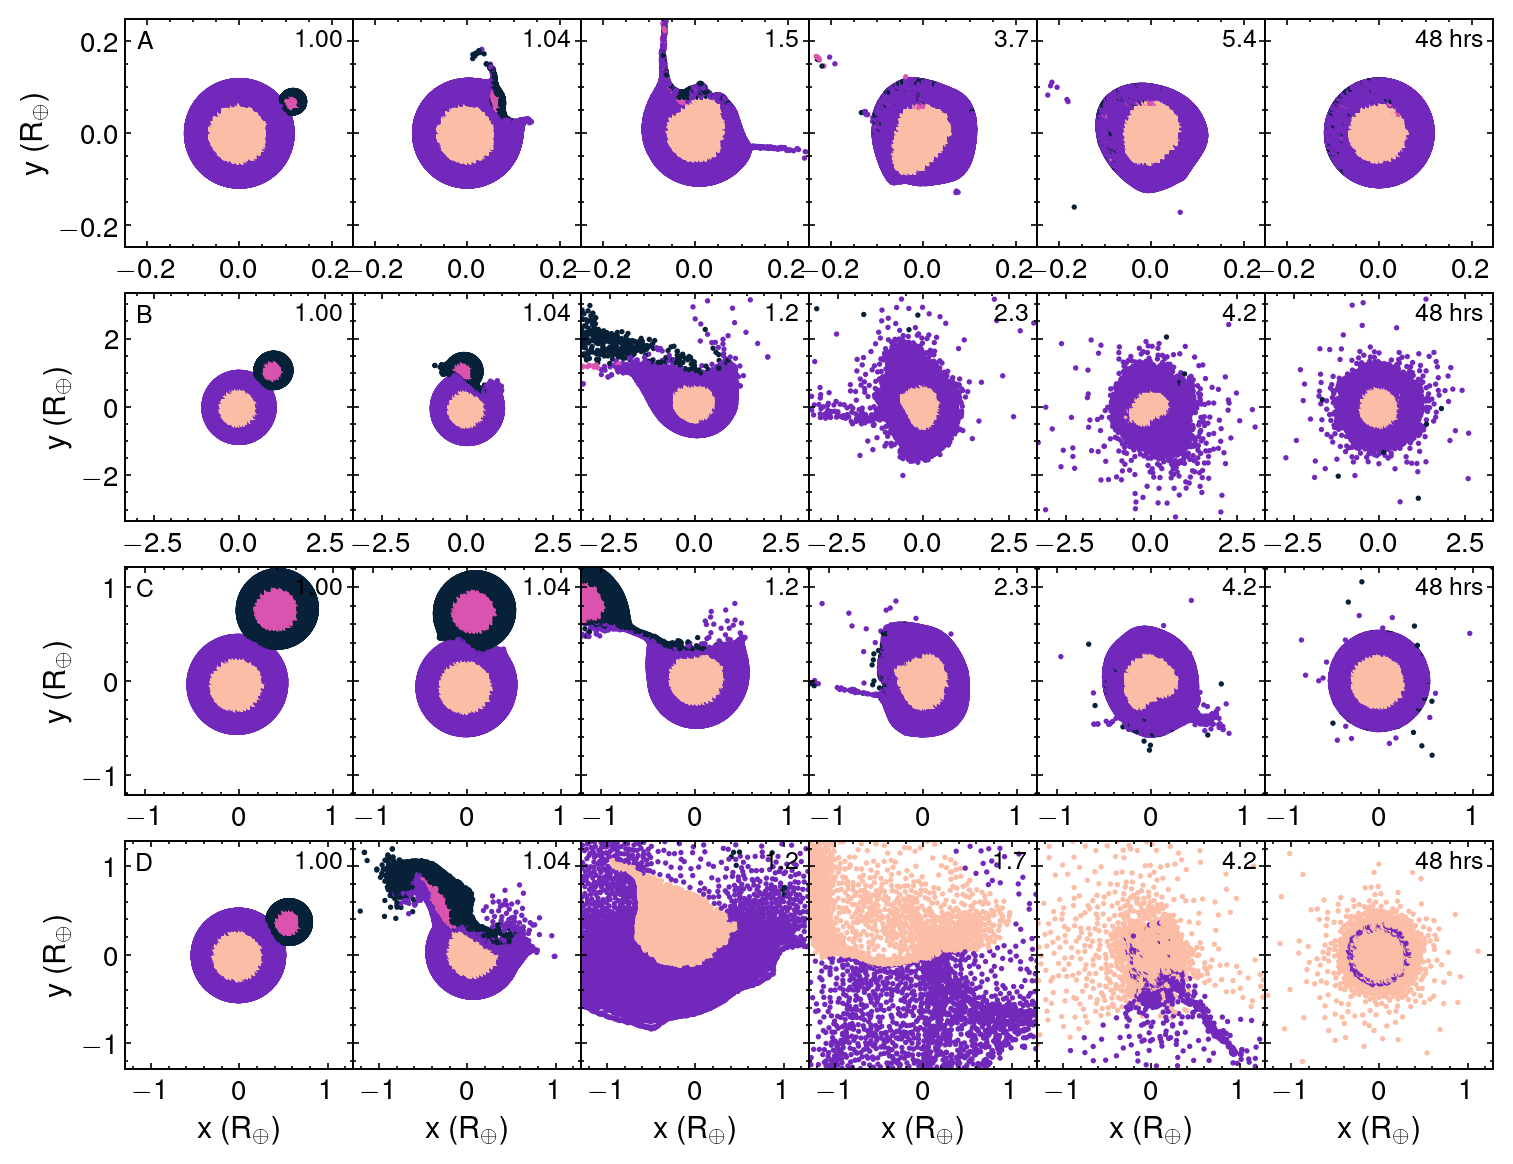

In [10]:
planit.multiplotseq([imp1,imp3,imp2,imp4],seqs=[seq,seq,seq,seq],types=['mat'],zoom=[8.1,2.4,3.3,6.2],scale='earth',uppercaselab=True)

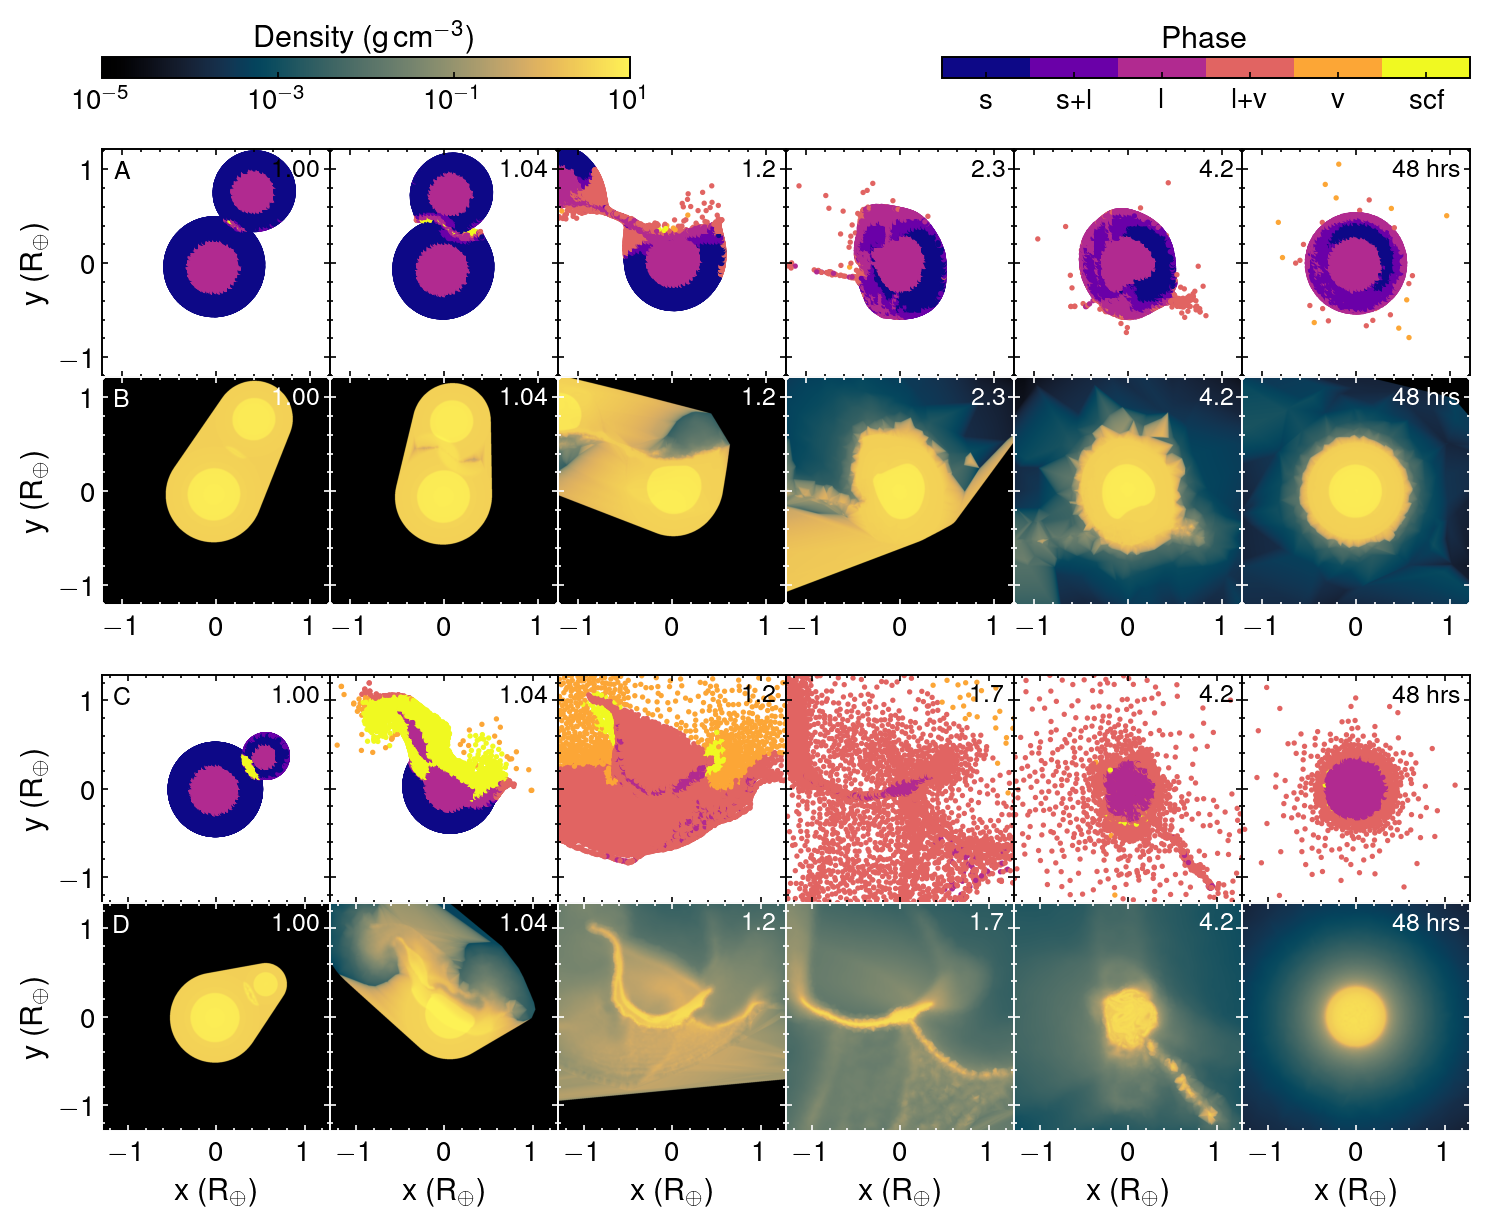

In [6]:
planit.multiplotseq([imp2,imp4],seqs=[seq,seq],types=['phase','rho'],zoom=[3.3,6.2],scale='earth',uppercaselab=True)